# Лабораторная работа № 1.3
## *Извлечение признаков из текста*
по курсу Технологии обработки естественного языка  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Коротеева Олеся В.  
**выполнил:** Янкин Иван Ю.  
**группа:** М4121

## загрузка признаков

In [2]:
import pandas as pd
import numpy as np

# Options for pandas
pd.options.display.max_columns = 50
pd.options.display.max_rows = 30

RANDOM_STATE = 42

In [3]:
target = pd.read_csv('./datasets/prepared_dataset.csv')
target = target.ttype.replace(-1, 0)
target.head(3)

0    0
1    0
2    0
Name: ttype, dtype: int64

In [4]:
names = ['tone_features', 'morph_features', 'tfidf_features', 
         'w2v_features', 'w2v_pretrained_features', 
         'fasttext_features', 'fasttext_features_pretrained']

datasets = []

for name in names:
    df = pd.read_csv(f'./features/{name}.csv')
    datasets.append(df)

## обучение моделей
- используются векторы: `тоновые`, `морфологические`, `tf-idf`, `w2v` кастомные, w2v предобученные `ruscorpora_upos_cbow_300_20_2019`, fasttext кастомные, fasttext предобученные `eowac_lemmas_none_fasttextskipgram_300_5_2020`
- классификатор: `Decision Tree`
- `вход -> выход:` `(datasets : list[DataFrame]) -> (results : dict)`

In [ ]:
from joblib import Parallel, delayed
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

feature_names = ['Tone', 'Morph', 'TF-IDF', 'W2V', 'W2V_Pre', 'FT', 'FT_Pre']

def train_and_score(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    return name, clf.score(X_test, y_test)

results_list = Parallel(n_jobs=-1)(
    delayed(train_and_score)(datasets[i], target, feature_names[i]) 
    for i in range(len(datasets))
)

results = dict(results_list)

for name, accuracy in results.items():
    print(f"{name:10}: точность = {accuracy:.4f}")

Параллельное обучение: 100%|██████████| 7/7 [00:00<00:00, 664.39it/s]


Tone      : точность = 0.5569
Morph     : точность = 0.5571
TF-IDF    : точность = 0.6624
W2V       : точность = 0.6071
W2V_Pre   : точность = 0.5915
FT        : точность = 0.6044
FT_Pre    : точность = 0.6001


## сравнение качества классификаторов

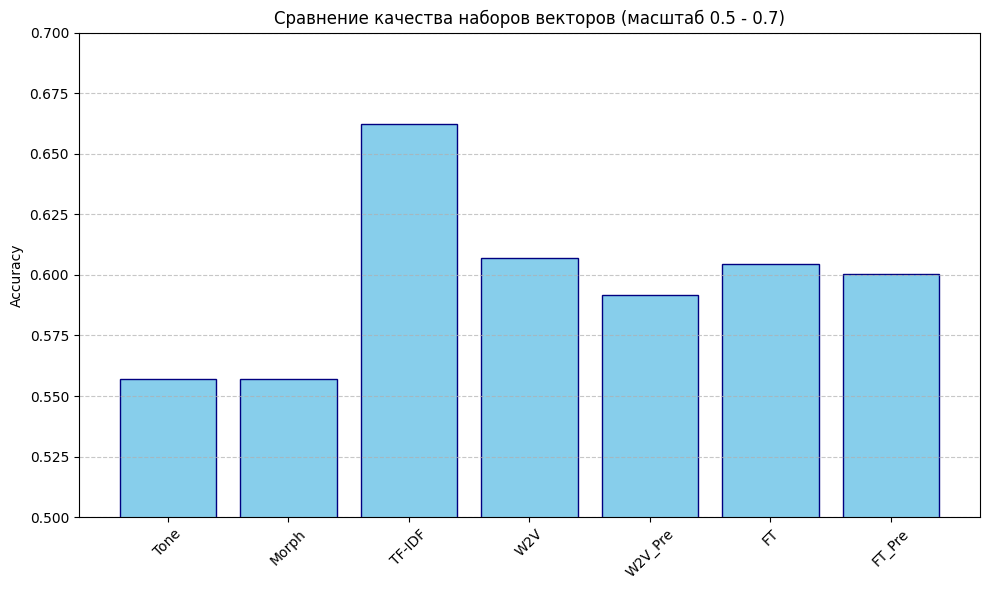

In [ ]:
import matplotlib.pyplot as plt

names = list(results.keys())
scores = list(results.values())

plt.figure(figsize=(10, 6))
plt.bar(names, scores, color='skyblue', edgecolor='navy')

plt.ylabel('Accuracy')
plt.title('Сравнение качества наборов векторов (масштаб 0.5 - 0.7)')
plt.ylim(0.5, 0.7) 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## выводы
- лучший классификатор обучен на: `TF-IDF`-признаках
- худший классификатор обучен на: `тоновых` и `морфологических` признаках
- классификаторы, обученные на самостоятельно обученных эмбеддингах, лучше классификаторов, использующих преобученные эмбеддинги: `W2V` лучше `W2V_Pre`, `FT` лучше `FT_Pre`